In [12]:
#importação de pandas
import pandas as pd

df = pd.read_csv(
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.25418/dados?formato=csv",
    sep=";",
    decimal=","
)


df["data"] = pd.to_datetime(
    df["data"],
    format="%d/%m/%Y"
)

print(df.head())
print(df.info())
#exibindo head e infos da tabela

        data  valor
0 2003-01-01  65.95
1 2003-02-01  65.45
2 2003-03-01  65.04
3 2003-04-01  65.36
4 2003-05-01  64.65
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   data    281 non-null    datetime64[ns]
 1   valor   281 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.5 KB
None


In [13]:
#aqui nós fizemos o head para saber se estava tudo certo com a tabela e o que esperar dela
#pegamos os 12 primeiros componentes
df.head(12)

,data,valor
0,2003-01-01,65.95
1,2003-02-01,65.45
2,2003-03-01,65.04
3,2003-04-01,65.36
4,2003-05-01,64.65
5,2003-06-01,65.17
6,2003-07-01,64.52
7,2003-08-01,64.66
8,2003-09-01,64.58
9,2003-10-01,64.04


In [14]:
df.shape
#só para saber quantas linhas e colunas tem

(281, 2)

In [15]:
media = df["valor"].mean()
mediana = df["valor"].median()
desvio_padrao = df["valor"].std()
minimo = df["valor"].min()
maximo = df["valor"].max()

print(f"Média: {media:.2f}".replace(".", ","))
print(f"Desvio padrão: {desvio_padrao:.2f}".replace(".", ","))
print(f"Mediana: {mediana:.2f}".replace(".", ","))
print(f"Mínimo: {minimo:.2f}".replace(".", ","))
print(f"Máximo: {maximo:.2f}".replace(".", ","))


#exibir média, mediana, desvio padrão, mínimos e máximos
#ferramentas estátisticas são muito úteis

Média: 89,85
Desvio padrão: 12,44
Mediana: 93,02
Mínimo: 64,04
Máximo: 111,56


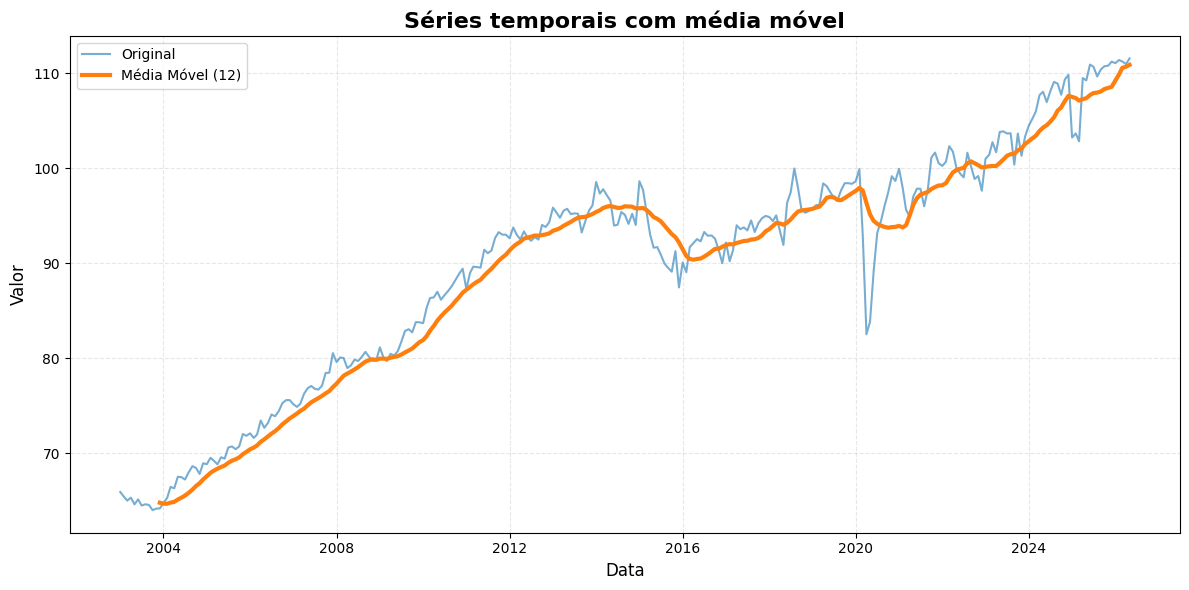

In [16]:
import matplotlib.pyplot as plt

#criar média móvel (12 períodos(meses))
df["media_movel"] = df["valor"].rolling(
    window=12
).mean()

plt.figure(figsize=(12,6))

# série original
plt.plot(
    df["data"],
    df["valor"],
    linewidth=1.5,
    alpha=0.6,
    label="Original"
)

# média móvel
plt.plot(
    df["data"],
    df["media_movel"],
    linewidth=3,
    label="Média Móvel (12)"
)

plt.title(
    "Séries temporais com média móvel",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Data",
    fontsize=12
)

plt.ylabel(
    "Valor",
    fontsize=12
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

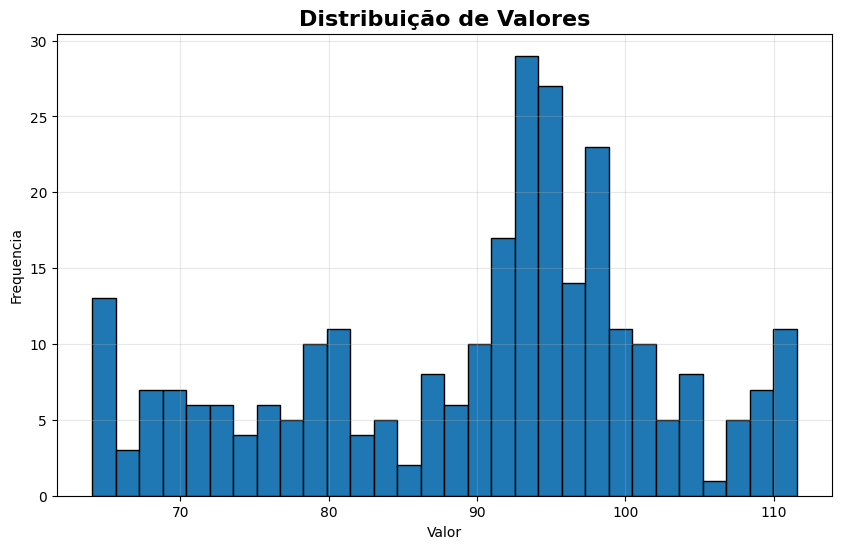

In [17]:
plt.figure(figsize=(10,6))

plt.hist(
    df["valor"],
    bins=30,
    edgecolor="black"
)

plt.title(
    "Distribuição de Valores",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Valor")

plt.ylabel("Frequencia")

plt.grid(alpha=0.3)

plt.show()

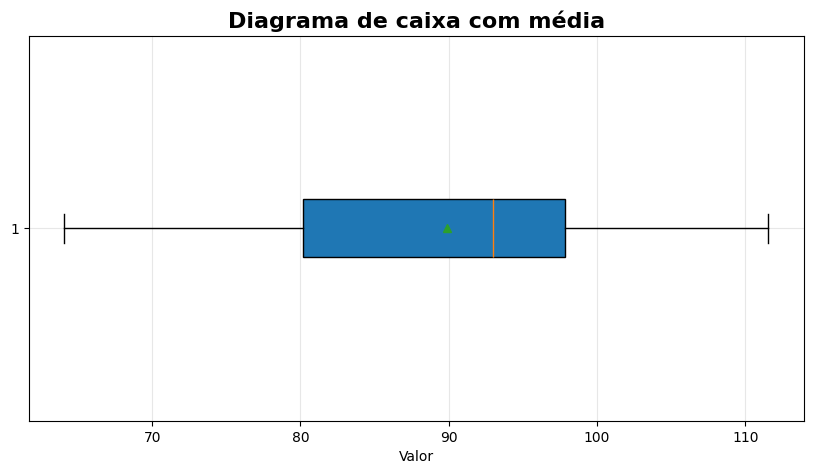

In [18]:
plt.figure(figsize=(10,5))

plt.boxplot(
    df["valor"],
    vert=False,
    showmeans=True,
    patch_artist=True
)

plt.title(
    "Diagrama de caixa com média",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Valor")

plt.grid(alpha=0.3)

plt.show()

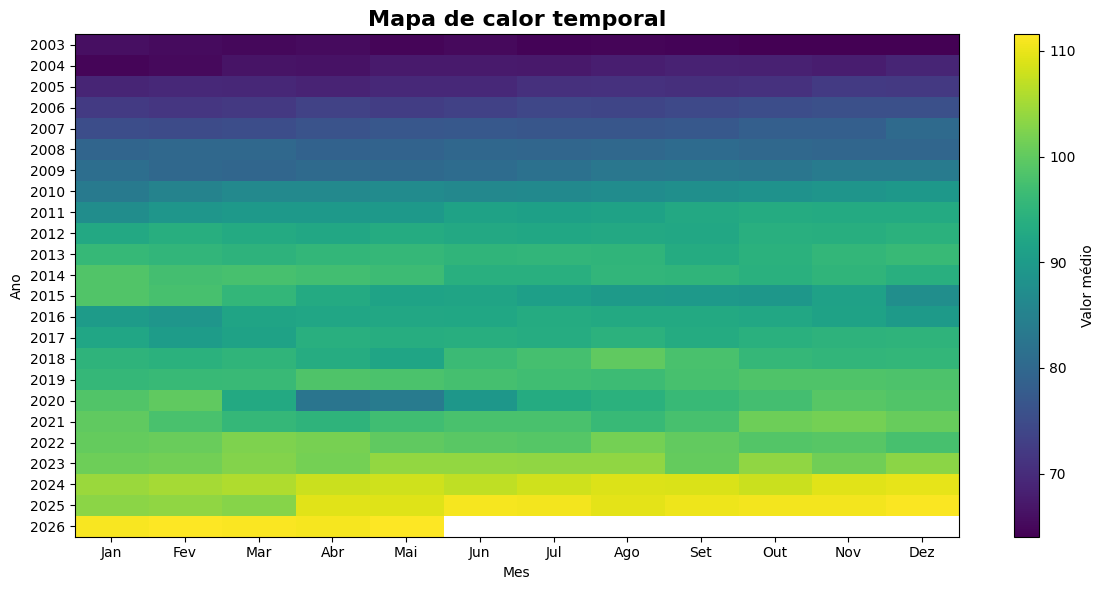

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month

heatmap_data = pd.pivot_table(
    df,
    values="valor",
    index="ano",
    columns="mes",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))

plt.imshow(
    heatmap_data,
    aspect='auto'
)

plt.colorbar(
    label="Valor médio"
)

plt.xticks(
    range(12),
    [
        "Jan","Fev","Mar","Abr",
        "Mai","Jun","Jul","Ago",
        "Set","Out","Nov","Dez"
    ]
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title(
    "Mapa de calor temporal",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mes")

plt.ylabel("Ano")

plt.tight_layout()

plt.show()
#efeitos da pandemia aparecem no gráfico

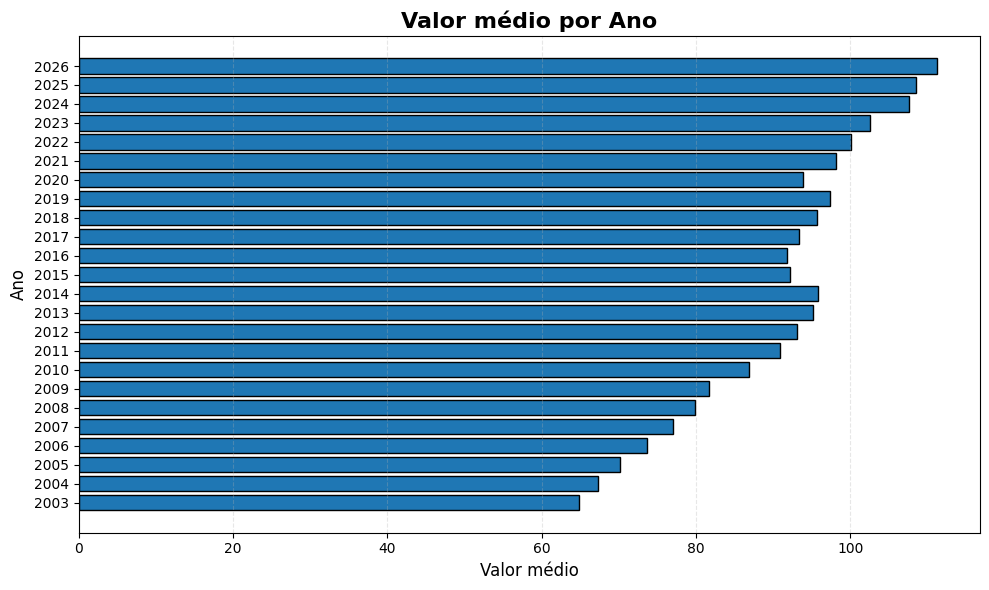

In [20]:
media_ano = df.groupby(
    df["data"].dt.year
)["valor"].mean()

plt.figure(figsize=(10,6))

plt.barh(
    media_ano.index.astype(str),
    media_ano.values,
    edgecolor="black"
)

plt.title(
    "Valor médio por Ano",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Valor médio",
    fontsize=12
)

plt.ylabel(
    "Ano",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

#no gráfico abaixo tem as informações da média agrupada por ano contidas na célula abaixo

In [21]:
#média agrupada por ano
df.groupby(
    df["data"].dt.year
)["valor"].mean()

,valor
data,
2003,64.820000
2004,67.269167
2005,70.170833
2006,73.679167
2007,76.977500
2008,79.850000
2009,81.715000
2010,86.920000
2011,90.915833
